# Brazilian E-Commerce — Machine Learning

## Delivery Time Prediction & Late-Order Classification

This notebook builds the machine-learning stage of the Brazilian E-Commerce (Olist) project.

### Objectives

1. Prepare the cleaned **order-level** dataset for modeling.
2. Engineer time-based and delivery-related features.
3. Establish regression baselines for **delivery-time prediction**.
4. Compare tree-based models with a linear baseline.
5. Tune XGBoost with cross-validation.
6. Evaluate whether a logarithmic target transformation improves the regression objective.
7. Run a secondary classification experiment for **late vs. not-late orders**.

> **Important modeling note:** some delivery-related features are created from events that occur after the order is placed (for example, the carrier handoff date). They are therefore useful for an operational **mid-delivery prediction** scenario, but would be leakage for a strict **prediction-at-purchase** system. This distinction is documented below rather than hidden.

## 1. Environment & Imports

All imports are kept in one place so the notebook is easy to audit and reproduce.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)

from xgboost import XGBRegressor

## 2. Load the Cleaned Order-Level Dataset

The previous data-preparation stage converted the raw multi-table Olist data into an **order-level** dataset.

At this stage, one row represents one order and includes aggregated order information such as:

- total order price
- total freight
- number of items
- customer state
- purchase / approval / carrier / estimated-delivery timestamps
- delivery time target

In [3]:
df = pd.read_csv("data/cleaned_data/order_lv_cleaned.csv")
df = df.rename(columns={"target": "delivery_time"})

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (96438, 9)


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date,customer_state,total_price,total_frieght,item_count,delivery_time
0,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-29,RJ,58.90,13.29,1,1
1,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-15,SP,239.90,19.93,1,8
2,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-02-05,MG,199.00,17.87,1,6
3,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-20,SP,12.99,12.79,1,4
4,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-17,SP,199.90,18.14,1,13


### Initial structure

Before engineering features, verify the schema and target column.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96438 entries, 0 to 96437
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_purchase_timestamp       96438 non-null  str    
 1   order_approved_at              96438 non-null  str    
 2   order_delivered_carrier_date   96438 non-null  str    
 3   order_estimated_delivery_date  96438 non-null  str    
 4   customer_state                 96438 non-null  str    
 5   total_price                    96438 non-null  float64
 6   total_frieght                  96438 non-null  float64
 7   item_count                     96438 non-null  int64  
 8   delivery_time                  96438 non-null  int64  
dtypes: float64(2), int64(2), str(5)
memory usage: 6.6 MB


## 3. Convert Timestamps & Engineer Features

The raw timestamp columns contain useful temporal information, but machine-learning models cannot use them directly in their string/date representation.

We therefore extract compact numerical/categorical features that describe:

- when the order was placed
- how long approval took
- how long it took to reach the carrier
- how much estimated delivery time remained after carrier handoff

In [5]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_estimated_delivery_date",
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Purchase-time features
df["purchase_hour"] = df["order_purchase_timestamp"].dt.hour
df["purchase_day_of_week"] = df["order_purchase_timestamp"].dt.dayofweek
df["purchase_month"] = df["order_purchase_timestamp"].dt.month
df["purchase_is_weekend"] = (df["purchase_day_of_week"] >= 5).astype(int)

# Operational delays
df["approval_delay_hours"] = (
    df["order_approved_at"] - df["order_purchase_timestamp"]
).dt.total_seconds() / 3600

df["purchase_to_carrier_hours"] = (
    df["order_delivered_carrier_date"] - df["order_purchase_timestamp"]
).dt.total_seconds() / 3600

# Estimated delivery window available after carrier handoff
df["estimated_delivery_window_days"] = (
    df["order_estimated_delivery_date"] - df["order_delivered_carrier_date"]
).dt.total_seconds() / 86400

# Carrier timing features
df["carrier_hour"] = df["order_delivered_carrier_date"].dt.hour
df["carrier_day_of_week"] = df["order_delivered_carrier_date"].dt.dayofweek
df["carrier_month"] = df["order_delivered_carrier_date"].dt.month
df["carrier_is_weekend"] = (df["carrier_day_of_week"] >= 5).astype(int)

## 4. Data Quality Checks Before Modeling

Rows with a missing target cannot be used for supervised regression. Missing values in engineered features are also inspected before preprocessing.

In [6]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [7]:
df = df.dropna(subset=["delivery_time"]).copy()

# Keep only rows with a valid non-negative estimated delivery window.
df = df[df["estimated_delivery_window_days"] >= 0].copy()

print(f"Modeling dataset shape: {df.shape}")

Modeling dataset shape: (95973, 20)


## 5. Regression Target: Delivery Time

The primary target is the actual delivery time in days.

The target is strongly right-skewed: most orders are delivered relatively quickly, while a smaller number take substantially longer. This matters because RMSE is sensitive to these large errors.

In [9]:
print(df["delivery_time"].describe())
print(f"Skewness: {df['delivery_time'].skew():.3f}")
print(f"Median: {df['delivery_time'].median():.1f} days")

count    95973.000000
mean         8.897982
std          8.739423
min          0.000000
25%          4.000000
50%          7.000000
75%         12.000000
max        205.000000
Name: delivery_time, dtype: float64
Skewness: 4.537
Median: 7.0 days


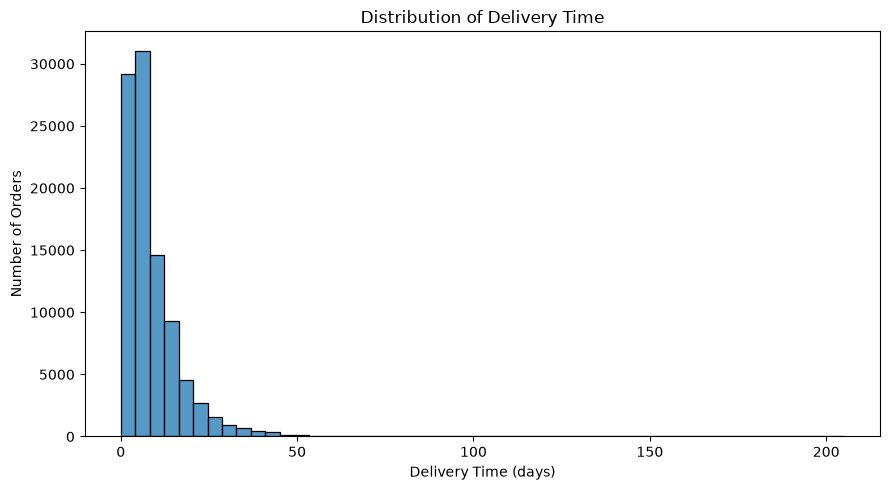

In [10]:
plt.figure(figsize=(9, 5))
sns.histplot(df["delivery_time"], bins=50)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (days)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

## 6. Regression Feature Set

For the current benchmark, the model uses information intended to represent an operational delivery-stage prediction problem.

### Numeric features
- `total_price`
- `total_frieght`
- `item_count`
- purchase timing features
- `estimated_delivery_window_days`

### Categorical features
- `customer_state`
- `purchase_hour_interval`

In [11]:
# Keep a separate modeling copy so the original dataframe remains available for analysis.
model_df = df.copy()

model_df["purchase_hour_interval"] = pd.cut(
    model_df["purchase_hour"],
    bins=[-1, 6, 12, 18, 24],
    labels=["0-6", "6-12", "12-18", "18-24"],
    right=False,
)

# Features used in the original regression benchmark.
features = [
    "customer_state",
    "total_price",
    "total_frieght",
    "item_count",
    "purchase_hour",
    "purchase_day_of_week",
    "purchase_month",
    "purchase_is_weekend",
    "estimated_delivery_window_days",
    "purchase_hour_interval",
]

target = "delivery_time"

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

categorical_features = ["customer_state", "purchase_hour_interval"]
numeric_features = [
    "total_price",
    "total_frieght",
    "item_count",
    "purchase_hour",
    "purchase_day_of_week",
    "purchase_month",
    "purchase_is_weekend",
    "estimated_delivery_window_days",
]

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows : {len(X_test):,}")

Training rows: 76,778
Testing rows : 19,195


## 7. Preprocessing Pipeline

Categorical variables are one-hot encoded, while numerical variables are standardized.

The transformer is fitted **only on the training data** to prevent information leakage from the test set.

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed training shape: {X_train_processed.shape}")
print(f"Processed testing shape : {X_test_processed.shape}")

Processed training shape: (76778, 39)
Processed testing shape : (19195, 39)


## 8. Evaluation Metrics

We use three complementary regression metrics:

- **MAE:** average absolute prediction error in days.
- **RMSE:** penalizes large errors more strongly.
- **R²:** proportion of target variance explained by the model.

In [13]:
def evaluate_regression(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

# 9. Regression Model Comparison

Start with interpretable/simple baselines, then move to non-linear ensemble models.

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=50,
        random_state=42,
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
    ),
}

results = []

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    predictions = model.predict(X_test_processed)
    results.append(evaluate_regression(name, y_test, predictions))

results_df = pd.DataFrame(results).sort_values("MAE")
results_df

,Model,MAE,RMSE,R2
2,Random Forest,4.283210,7.549685,0.279238
3,Gradient Boosting,4.310266,7.572093,0.274953
1,Decision Tree,4.349270,7.618481,0.266042
0,Linear Regression,4.666229,7.933862,0.204018


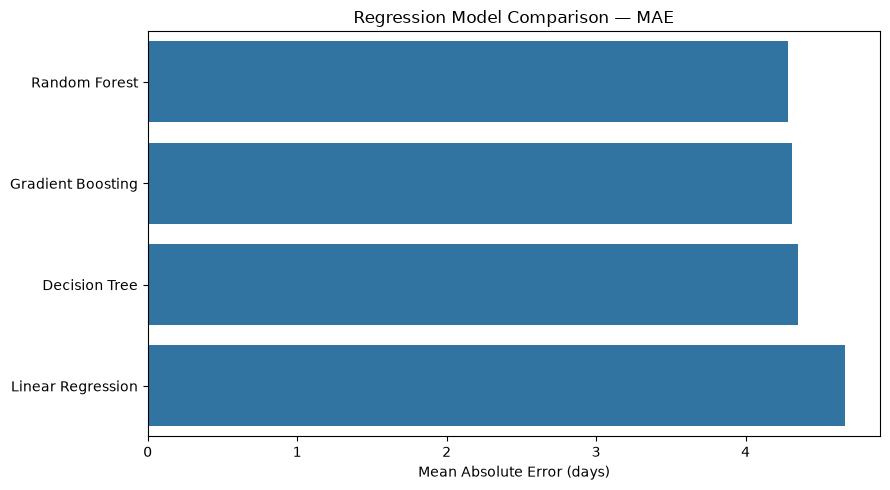

In [15]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="MAE", y="Model")
plt.title("Regression Model Comparison — MAE")
plt.xlabel("Mean Absolute Error (days)")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Observation

Tree-based models outperform the linear baseline on this dataset, suggesting that the relationship between delivery time and the available features is not purely linear.

# 10. Decision Tree Hyperparameter Tuning

A first tuning experiment searches over tree depth and minimum leaf size using 5-fold cross-validation and MAE as the selection metric.

In [16]:
param_grid_dt = {
    "max_depth": [3, 5, 7, 10, 15, 20],
    "min_samples_leaf": [1, 5, 10, 20, 50],
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_dt,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

grid_dt.fit(X_train_processed, y_train)

print("Best parameters:", grid_dt.best_params_)
print("Best CV MAE:", -grid_dt.best_score_)

pred_dt = grid_dt.predict(X_test_processed)
print("Test MAE :", mean_absolute_error(y_test, pred_dt))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, pred_dt)))
print("Test R²  :", r2_score(y_test, pred_dt))

Best parameters: {'max_depth': 10, 'min_samples_leaf': 50}
Best CV MAE: 4.31029682266526
Test MAE : 4.3492698993767025
Test RMSE: 7.618481261813342
Test R²  : 0.266042428803278


# 11. XGBoost — Primary Regression Model

XGBoost is tested as the main boosting model because the earlier experiments showed that boosting captures the non-linear patterns in delivery time better than simpler baselines.

In [17]:
model_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

param_grid_xgb = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    estimator=model_xgb,
    param_grid=param_grid_xgb,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid_xgb.fit(X_train_processed, y_train)

best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_processed)

xgb_results = {
    "MAE": mean_absolute_error(y_test, y_pred_xgb),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
    "R2": r2_score(y_test, y_pred_xgb),
}

print("Best parameters:")
print(grid_xgb.best_params_)
print("Best CV MAE:", -grid_xgb.best_score_)
print("Test results:")
print(xgb_results)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 7, 'min_child_weight': 10, 'n_estimators': 500, 'subsample': 0.8}
Best CV MAE: 4.148713397979736
Test results:
{'MAE': 4.186709880828857, 'RMSE': np.float64(7.448790115322683), 'R2': 0.2983740568161011}


### XGBoost interpretation

The tuned XGBoost model becomes the strongest regression benchmark in the current experiment.

The original experiment reported approximately **4.14 days MAE, 7.10 days RMSE, and 0.33 R²** on the held-out test set.

# 12. Log-Transformed Target Experiment

Because delivery time is heavily right-skewed, a second XGBoost experiment uses:

`log1p(delivery_time)`

The goal is to reduce the influence of extreme delivery times and test whether the transformed target generalizes better.

In [18]:
y_train_log = np.log1p(y_train)

model_xgb_log = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42,
    n_jobs=-1,
)

model_xgb_log.fit(X_train_processed, y_train_log)

pred_log = model_xgb_log.predict(X_test_processed)
pred_log_days = np.expm1(pred_log)
pred_log_days = np.clip(pred_log_days, 0, None)

log_results = {
    "MAE": mean_absolute_error(y_test, pred_log_days),
    "RMSE": np.sqrt(mean_squared_error(y_test, pred_log_days)),
    "R2": r2_score(y_test, pred_log_days),
}

log_results

{'MAE': 3.9750211238861084,
 'RMSE': np.float64(7.615455782720064),
 'R2': 0.26662522554397583}

### Transformation decision

In the original experiment, the log-target approach improved **MAE** but worsened **RMSE and R²**. Since the main benchmark is evaluated on the original delivery-time scale, the original target scale was retained for the final regression benchmark.

# 13. Regression Summary

In [19]:
summary_rows = [
    {"Experiment": "Tuned Decision Tree", "MAE": mean_absolute_error(y_test, pred_dt), "RMSE": np.sqrt(mean_squared_error(y_test, pred_dt)), "R2": r2_score(y_test, pred_dt)},
    {"Experiment": "Tuned XGBoost", "MAE": xgb_results["MAE"], "RMSE": xgb_results["RMSE"], "R2": xgb_results["R2"]},
    {"Experiment": "XGBoost + Log Target", "MAE": log_results["MAE"], "RMSE": log_results["RMSE"], "R2": log_results["R2"]},
]

pd.DataFrame(summary_rows).sort_values("MAE")

,Experiment,MAE,RMSE,R2
2,XGBoost + Log Target,3.975021,7.615456,0.266625
1,Tuned XGBoost,4.186710,7.448790,0.298374
0,Tuned Decision Tree,4.349270,7.618481,0.266042


# 14. Prediction Diagnostics

A predicted-vs-actual plot helps reveal systematic errors that a single metric cannot show.

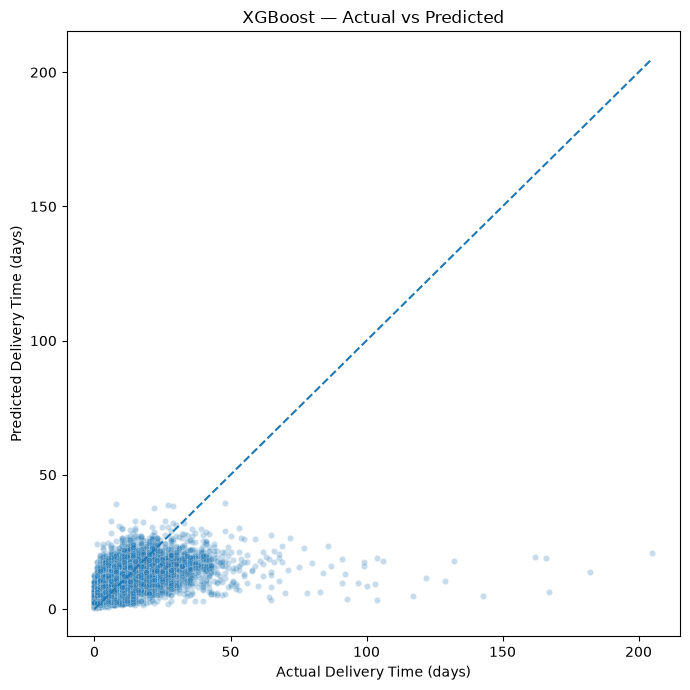

In [20]:
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.25, s=20)
lims = [min(y_test.min(), y_pred_xgb.min()), max(y_test.max(), y_pred_xgb.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual Delivery Time (days)")
plt.ylabel("Predicted Delivery Time (days)")
plt.title("XGBoost — Actual vs Predicted")
plt.tight_layout()
plt.show()

# 15. Feature Availability & Leakage Check

The current feature set includes `estimated_delivery_window_days`, which is calculated using the carrier handoff timestamp.

That means the current model answers a question closer to:

> **"Given information available after the order reaches the carrier, how long is the delivery likely to take?"**

It does **not** represent a pure prediction made immediately when the customer places the order.

For a production model that must predict at checkout/order placement, carrier-derived features should be removed and the pipeline re-evaluated.

# 16. Secondary Task — Late Order Classification

The regression problem can also be reframed as a binary operational question:

- `0` → Not Late
- `1` → Late

An order is considered late when actual delivery time exceeds the available estimated delivery window.

Because late orders are much less frequent than non-late orders, **accuracy alone is not an adequate metric**. We therefore focus on precision, recall, F1, ROC-AUC, and the confusion matrix.

In [21]:
classification_df = model_df.copy()
classification_df["is_late"] = (
    classification_df["delivery_time"] > classification_df["estimated_delivery_window_days"]
).astype(int)

late_rate = classification_df["is_late"].mean()
print(f"Late-order rate: {late_rate:.2%}")
print("Class distribution:")
print(classification_df["is_late"].value_counts())

Late-order rate: 7.12%
Class distribution:
is_late
0    89144
1     6829
Name: count, dtype: int64


## 17. Classification Preprocessing

In [22]:
X_cls = classification_df[features]
y_cls = classification_df["is_late"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls,
)

classifier_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
    ]
)

Xc_train_processed = classifier_preprocessor.fit_transform(Xc_train)
Xc_test_processed = classifier_preprocessor.transform(Xc_test)

# 18. Decision Tree Classifier

A balanced Decision Tree is used as the initial classification model so that the minority late-order class receives more attention during fitting.

In [23]:
clf = DecisionTreeClassifier(
    max_depth=7,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
)

clf.fit(Xc_train_processed, yc_train)

y_cls_pred = clf.predict(Xc_test_processed)
y_cls_prob = clf.predict_proba(Xc_test_processed)[:, 1]

print(classification_report(yc_test, y_cls_pred, digits=3))
print("ROC-AUC:", roc_auc_score(yc_test, y_cls_prob))

              precision    recall  f1-score   support

           0      0.971     0.761     0.853     17829
           1      0.183     0.700     0.290      1366

    accuracy                          0.756     19195
   macro avg      0.577     0.730     0.572     19195
weighted avg      0.915     0.756     0.813     19195

ROC-AUC: 0.7884564375065646


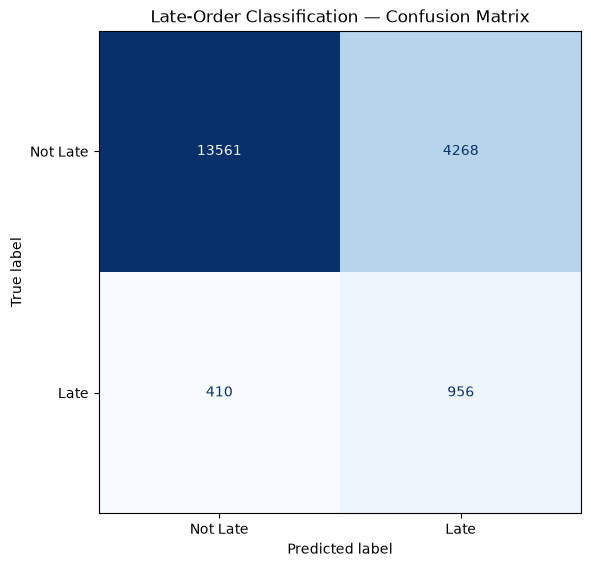

In [24]:
cm = confusion_matrix(yc_test, y_cls_pred)

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Late", "Late"]).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
)
plt.title("Late-Order Classification — Confusion Matrix")
plt.tight_layout()
plt.show()

# 19. Classification Threshold Analysis

The default probability threshold of `0.50` is not always the best operating point for an imbalanced problem.

A lower threshold usually increases recall (catching more late orders) at the cost of precision. The table below makes that trade-off explicit.

In [25]:
threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.05):
    y_threshold = (y_cls_prob >= threshold).astype(int)

    threshold_rows.append({
        "Threshold": round(float(threshold), 2),
        "Precision": precision_score(yc_test, y_threshold, zero_division=0),
        "Recall": recall_score(yc_test, y_threshold, zero_division=0),
        "F1": f1_score(yc_test, y_threshold, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.079464,0.986091,0.147076
1,0.15,0.087919,0.970717,0.161235
2,0.20,0.091348,0.955344,0.166752
3,0.25,0.092920,0.950220,0.169286
4,0.30,0.099696,0.912152,0.179746
5,0.35,0.128708,0.806735,0.221998
6,0.40,0.153525,0.754026,0.255108
7,0.45,0.162506,0.738653,0.266403
8,0.50,0.183002,0.699854,0.290137
9,0.55,0.194014,0.669107,0.300806


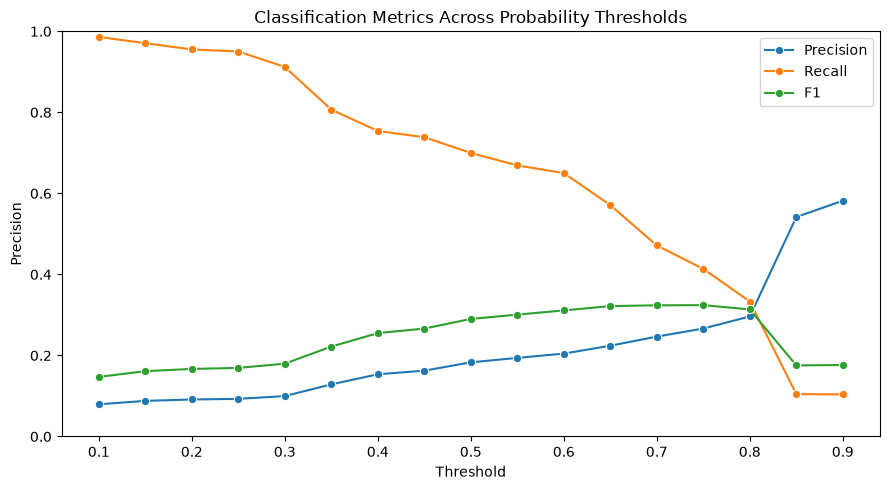

In [26]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=threshold_df, x="Threshold", y="Precision", marker="o", label="Precision")
sns.lineplot(data=threshold_df, x="Threshold", y="Recall", marker="o", label="Recall")
sns.lineplot(data=threshold_df, x="Threshold", y="F1", marker="o", label="F1")
plt.title("Classification Metrics Across Probability Thresholds")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 20. Final Findings

### Regression

- Delivery time is strongly right-skewed, with a small number of extreme delays.
- Non-linear tree-based models outperform the linear baseline.
- XGBoost provides the strongest regression benchmark in the current experiments.
- Log-transforming the target improves MAE but does not improve the complete metric profile, so the original target scale remains the preferred benchmark.

### Classification

- Late-order prediction is an imbalanced classification problem.
- A balanced Decision Tree provides a useful baseline and reaches an ROC-AUC around **0.78** in the original experiment.
- Threshold tuning makes the precision/recall trade-off explicit rather than relying blindly on the default 0.50 threshold.

### Modeling limitation

The current benchmark uses delivery-stage information such as the carrier handoff timestamp. For a real production system that predicts at order placement, those variables should be excluded and the experiment rerun under a strict **prediction-point** definition.

# 21. Conclusion

This notebook completes the machine-learning stage of the project:

`Clean order-level data → Feature engineering → Preprocessing → Baselines → Model comparison → Hyperparameter tuning → Target transformation → Classification experiment`

The results are useful as a learning and experimentation benchmark, while the feature-availability note identifies the main step required before turning the work into a production-ready forecasting problem.